In [94]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import f_classif,chi2
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier



read dataset

In [51]:
FILE_PATH = os.path.join(os.getcwd(), "..", "dataset", "churn-data.csv")
df = pd.read_csv(FILE_PATH)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [53]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [54]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [55]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [56]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


* `EDA`

In [57]:
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [58]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [59]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [60]:
#target
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [61]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [62]:
df['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

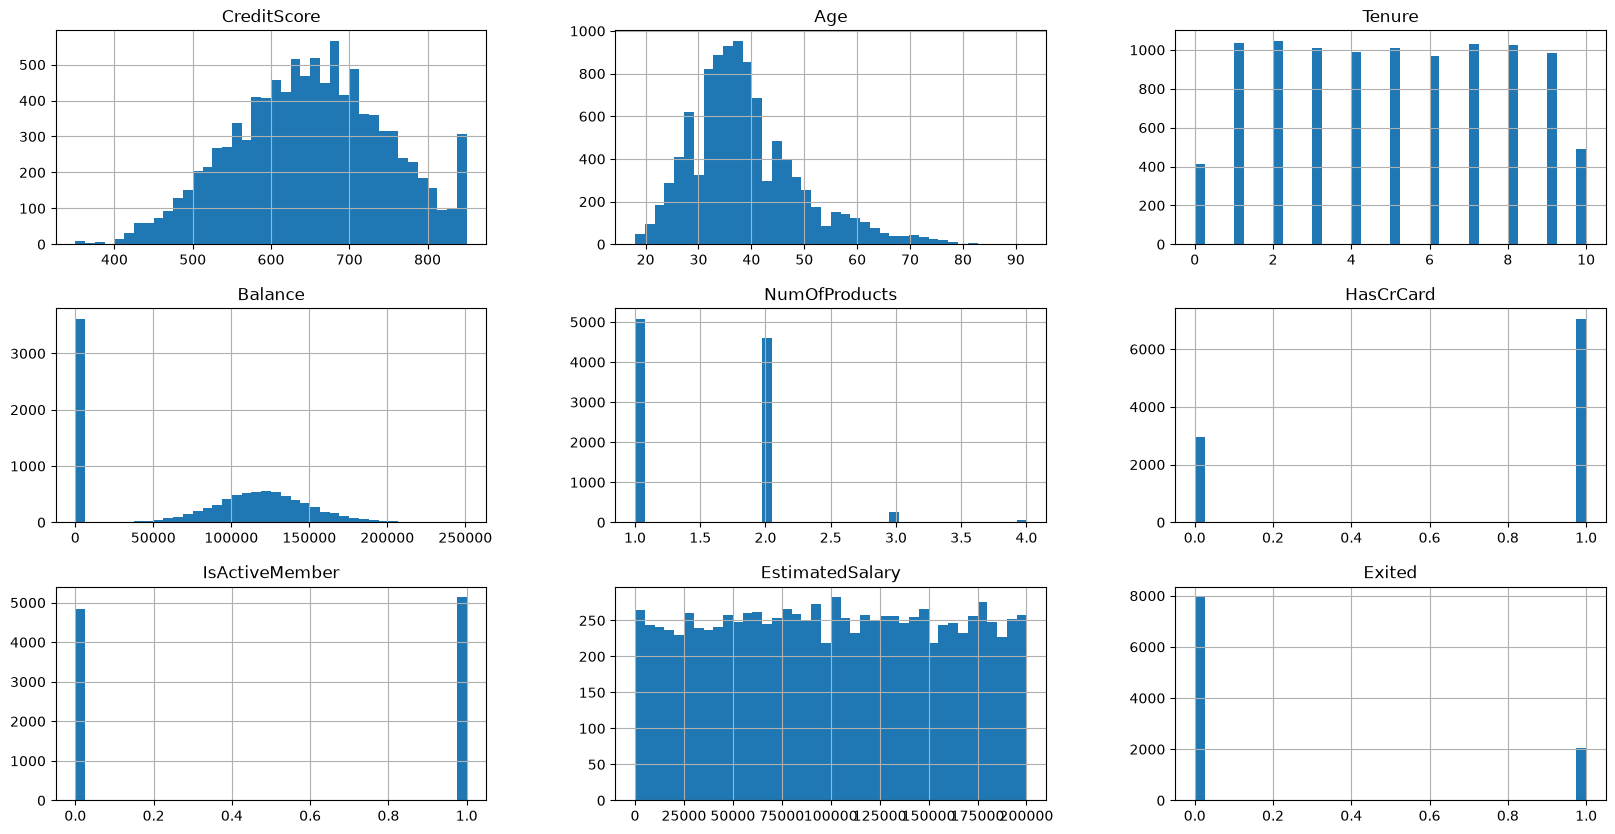

In [63]:
df.hist(bins=40,figsize=(20,10))
plt.show()

In [64]:
df.drop(index=df[df["Age"]>80].index.to_list(),axis=0,inplace=True)

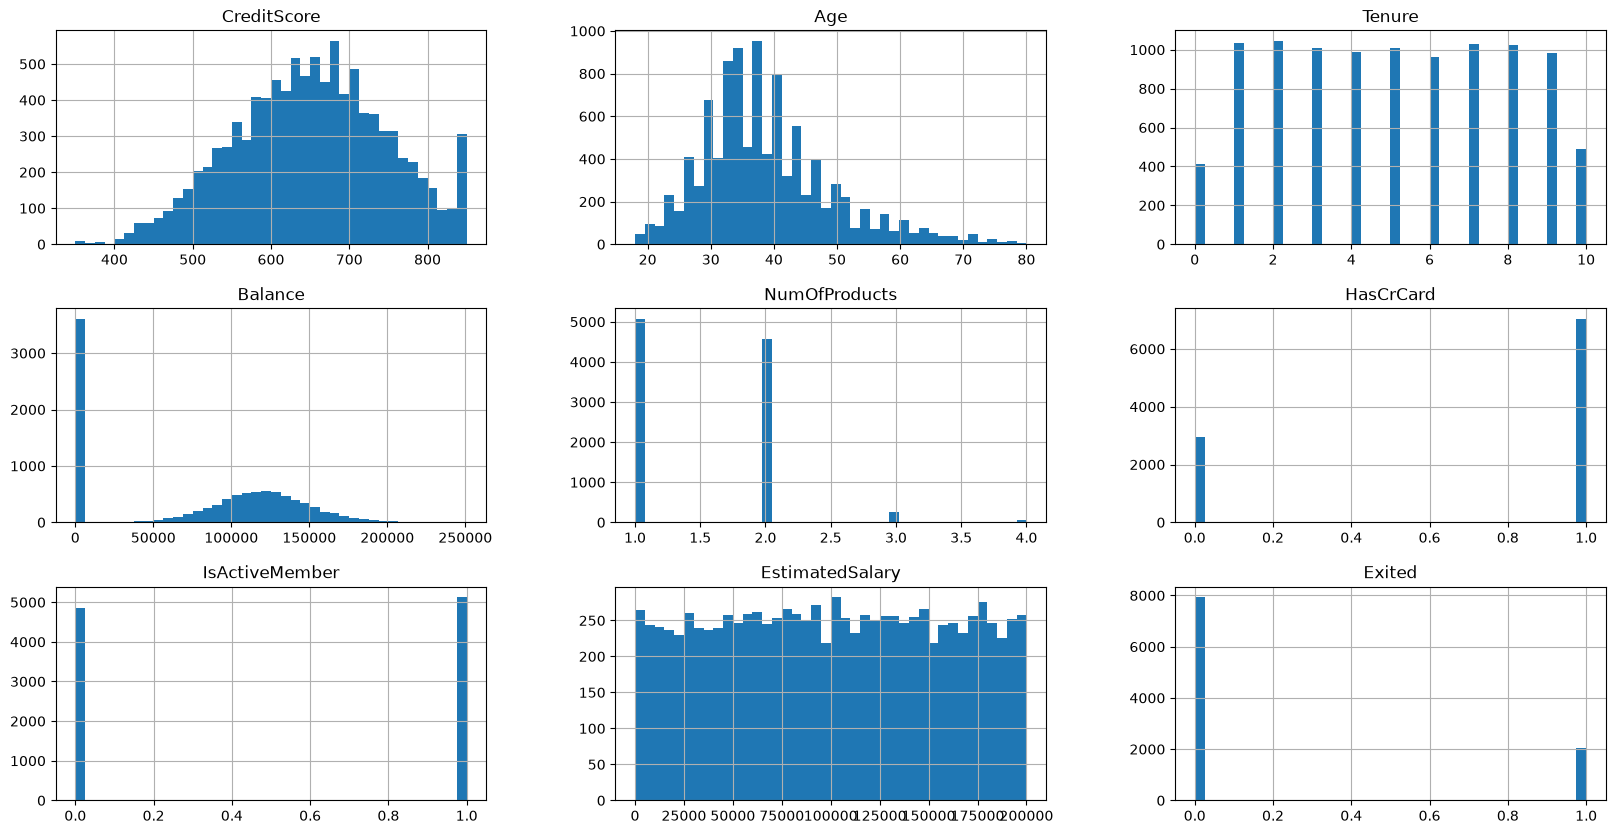

In [65]:
df.hist(bins=40,figsize=(20,10))
plt.show()

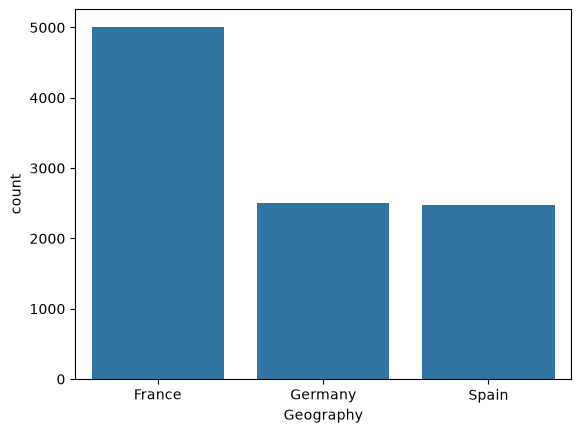

In [66]:
sns.countplot(data=df,x='Geography',order=df['Geography'].value_counts().index.to_list())
plt.show()

<Axes: xlabel='Gender', ylabel='count'>

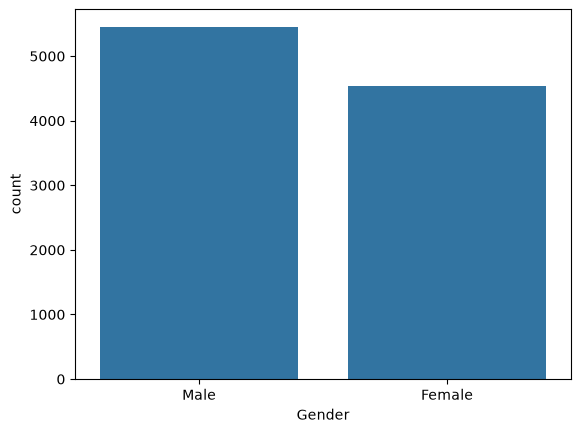

In [67]:
sns.countplot(data=df,x="Gender",order=df['Gender'].value_counts().index.to_list())

<Axes: ylabel='EstimatedSalary'>

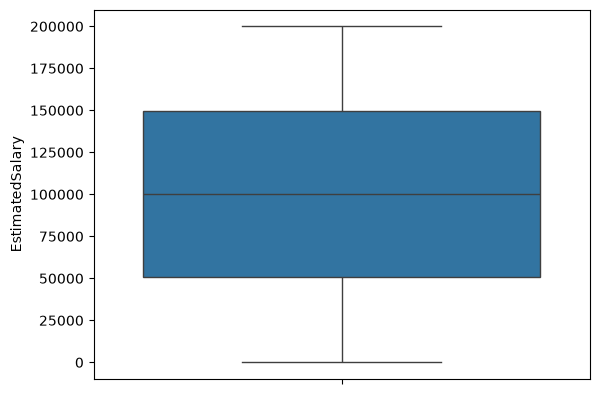

In [68]:
sns.boxplot(data=df,y='EstimatedSalary')

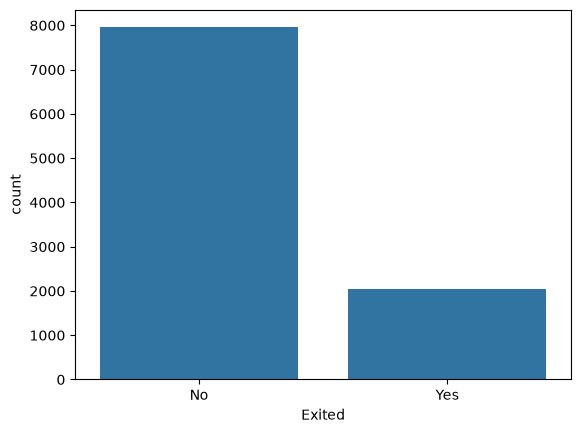

In [69]:
sns.countplot(data=df,x="Exited")
plt.xticks(labels=['No','Yes'],ticks=[0,1])
plt.show()

<Axes: xlabel='Gender', ylabel='EstimatedSalary'>

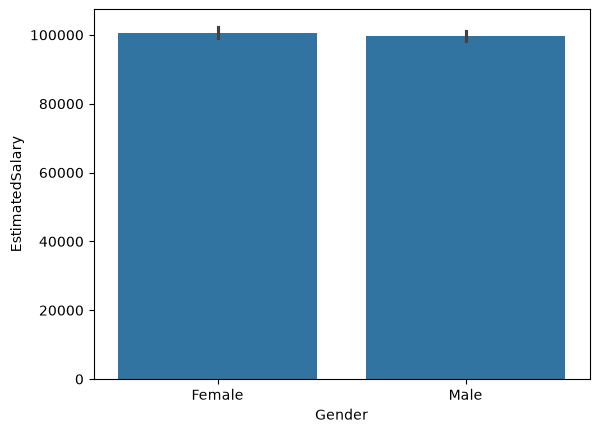

In [70]:
sns.barplot(data=df,x='Gender',y='EstimatedSalary')

<Axes: xlabel='Tenure', ylabel='count'>

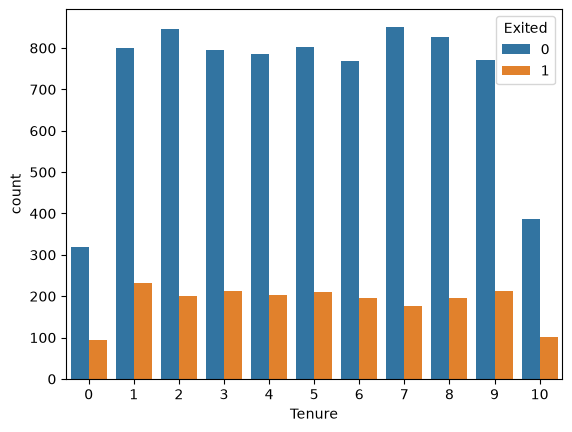

In [71]:
sns.countplot(data=df,x="Tenure",hue="Exited")

<Axes: xlabel='Geography', ylabel='count'>

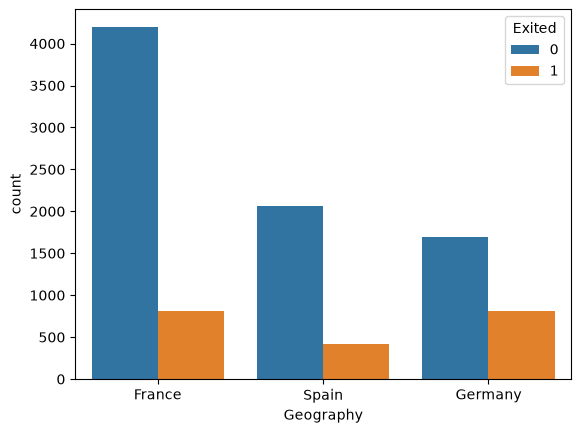

In [72]:
sns.countplot(data=df,x="Geography",hue="Exited")

In [74]:
# to X & y
X = df.drop(columns=['Exited'])
y = df['Exited']

# split to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=45, stratify=y)

# Check shapes
print('X_train.shape \t', X_train.shape)
print('y_train.shape \t', y_train.shape)
print('***'*10)
print('X_test.shape \t', X_test.shape)
print('y_test.shape \t', y_test.shape)

X_train.shape 	 (7990, 10)
y_train.shape 	 (7990,)
******************************
X_test.shape 	 (1998, 10)
y_test.shape 	 (1998,)


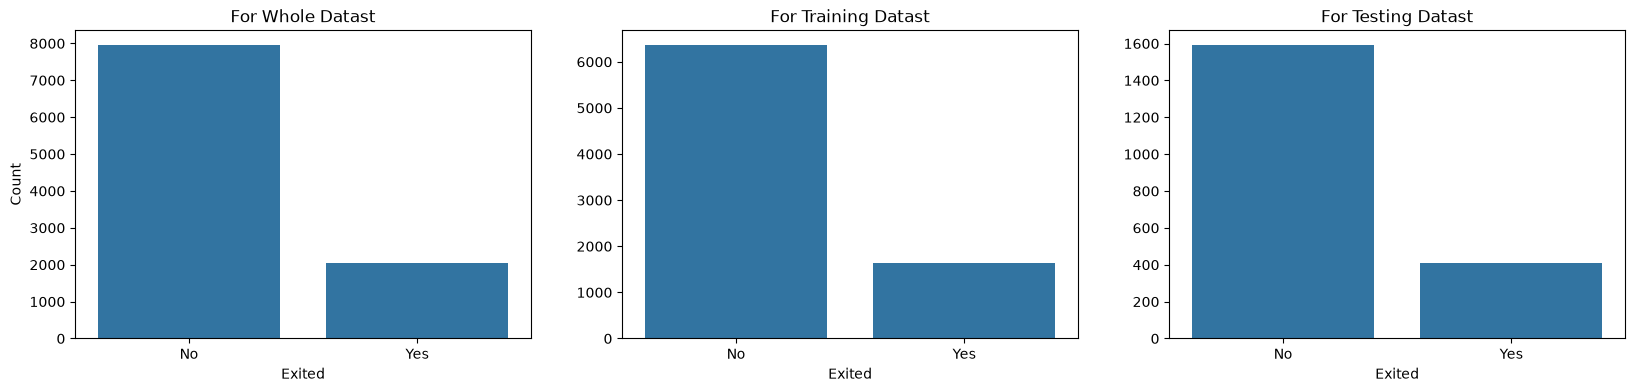

In [75]:
# plottting to check
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

# Whole dataset
plt.sca(ax[0])
sns.countplot(x=y)
plt.title('For Whole Datast')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

# train
plt.sca(ax[1])
sns.countplot(x=y_train)
plt.title('For Training Datast')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

# test
plt.sca(ax[2])
sns.countplot(x=y_test)
plt.title('For Testing Datast')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

In [76]:
# slice cols
num_cols = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']
categ_cols = ['Geography', 'Gender']
ready_cols = list(set(X_train.columns) - set(num_cols) - set(categ_cols))

In [77]:
# Numerical cols (num_cols) with Target col --> ANOVA
_, p_val = f_classif(X=X_train[num_cols], y=y_train)
p_val    # p_value ~ 0.05 --> Reject H0 --> There is an association between features and target

array([1.15359217e-149, 9.12989970e-002, 3.56368021e-025, 6.16127881e-001])

In [78]:
# Categorical cols (categ_cols) with Target col --> chi2
_, p_val = chi2(X=OrdinalEncoder().fit_transform(X_train[categ_cols]), y=y_train)
p_val  # p_value ~ 0.05 --> Reject H0 --> There is an association between features and target

array([1.56448286e-03, 5.13986341e-10])

In [79]:
# Ready cols (ready_cols) with Target col --> chi2
_, p_val = chi2(X=X_train[ready_cols], y=y_train)
p_val   # p_value ~ 0.05 --> Reject H0 --> There is an association between features and target

array([6.55133468e-02, 6.69284702e-01, 6.36015039e-02, 7.15759804e-22])

In [80]:
# Pipeline

# Numerical: num_cols --> Imputing using median, and Standardization
# Categroical: categ_cols --> Imputing using mode, and OHE
# Ready: ready_cols --> Imputing using mode


# For Numerical
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

# For Categorical
categ_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(sparse_output=False, drop="first"))
])

# For Ready
ready_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

# Combine all
preporcessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("categ", categ_pipeline, categ_cols),
    ("ready", ready_pipeline, ready_cols)
])


# Apply
X_train_final = preporcessor.fit_transform(X_train)
X_test_final = preporcessor.transform(X_test)

In [82]:
# Dump prprocessor
ARTIFACTS_FOLDER_PATH = os.path.join(os.getcwd(), "..", "artifacts")
os.makedirs(ARTIFACTS_FOLDER_PATH, exist_ok=True)

joblib.dump(preporcessor, os.path.join(ARTIFACTS_FOLDER_PATH, "preporcessor.pkl"))

['e:\\FCAI\\AI\\DEPI\\Matrial\\Materials Slides\\PPTX\\NTI\\notebooks\\..\\artifacts\\preporcessor.pkl']

handle imblance data


In [83]:
# 2. Using UnderSampling or OverSampling

# Oversampling
over = SMOTE(sampling_strategy=0.7, k_neighbors=5, random_state=45)
X_train_resampled, y_train_resampled = over.fit_resample(X_train_final, y_train)

Logisitic regression 


In [84]:
# 1. Using logisit -- without considering the imabalancing data
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final, y_train)

# Predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# using f1-score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log  = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using Logistic model for Training Dataset is {score_train_log*100:.3f}')
print(f'The f1_score using Logistic model for Testing Dataset is {score_test_log*100:.3f}')

The f1_score using Logistic model for Training Dataset is 30.888
The f1_score using Logistic model for Testing Dataset is 37.500


In [85]:
# 3. Using logisit -- using smote
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# using f1-score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log  = f1_score(y_test, y_pred_test_log)

print(f'The f1_score using Logistic model for Training Dataset is {score_train_log*100:.3f}')
print(f'The f1_score using Logistic model for Testing Dataset is {score_test_log*100:.3f}')

The f1_score using Logistic model for Training Dataset is 49.743
The f1_score using Logistic model for Testing Dataset is 50.420


*`Random forest`

In [91]:
forest_clf=RandomForestClassifier(n_estimators=150,max_depth=5,random_state=42)

forest_clf.fit(X_train_final, y_train)

y_pred_train_forest=forest_clf.predict(X_train_final)
y_pred_test_forest=forest_clf.predict(X_test_final)

score_train_forest = f1_score(y_train,y_pred_train_forest)
score_test_forest = f1_score(y_test,y_pred_test_forest)


print(f'The f1_score using RF model for Training Dataset with class_weights is {score_train_forest*100:.3f}')
print(f'The f1_score using RF model for Testing Dataset with class_weights is {score_test_forest*100:.3f}')

The f1_score using RF model for Training Dataset with class_weights is 45.887
The f1_score using RF model for Testing Dataset with class_weights is 44.485


In [102]:
forest_clf=RandomForestClassifier(n_estimators=150,max_depth=5,random_state=42)

forest_clf_paramter = forest_clf.fit(X_train_resampled,y_train_resampled)

# Predict and evaluate
y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_foerst = forest_clf.predict(X_test_final)

# Using f1_score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_foerst)

print(f'The f1_score using RF model for Training Dataset with SMOTE is {score_train_forest*100:.3f}')
print(f'The f1_score using RF model for Testing Dataset with SMOTE is {score_test_forest*100:.3f}')

The f1_score using RF model for Training Dataset with SMOTE is 61.579
The f1_score using RF model for Testing Dataset with SMOTE is 59.843


In [99]:
forest_clf_base= RandomForestClassifier(n_estimators=150,max_depth=5,random_state=42)

parmter={
    "n_estimators":np.arange(50,500,50),
    "max_depth":np.arange(6,10)
}
forest_clf_gred= GridSearchCV(estimator=forest_clf_base,param_grid=parmter,scoring="f1" , n_jobs=-1,cv = 5 )
forest_clf_gred.fit(X_train_final,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([6, 7, 8, 9]), 'n_estimators': array([ 50, 1...50, 400, 450])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the ver

In [100]:
forest_clf_gred.best_params_

{'max_depth': np.int64(9), 'n_estimators': np.int64(50)}

In [105]:
joblib.dump(forest_clf_paramter ,os.path.join(ARTIFACTS_FOLDER_PATH,"forest_tuned.pkl"))

['e:\\FCAI\\AI\\DEPI\\Matrial\\Materials Slides\\PPTX\\NTI\\notebooks\\..\\artifacts\\forest_tuned.pkl']